<a href="https://colab.research.google.com/github/vinicius-mattoso/industrial-rul-predictive-maintenance/blob/main/notebooks/02_health_state_classification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Health State Classification for Predictive Maintenance

Neste notebook vamos transformar o problema de Remaining Useful Life (RUL) em uma tarefa de classificação operacional.

Em vez de prever exatamente quantos ciclos restam até a falha, o objetivo será classificar cada leitura do equipamento em um dos seguintes estados:

- Healthy
- Degrading
- Critical

Essa abordagem é bastante útil em ambientes industriais, pois facilita a tomada de decisão operacional, priorização de manutenção e criação de sistemas de alerta.

In [1]:
import warnings

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    accuracy_score,
    f1_score,
    precision_score,
    recall_score
)

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier

from xgboost import XGBClassifier

warnings.filterwarnings("ignore")

RANDOM_STATE = 42

pd.set_option("display.max_columns", 100)

sns.set_theme(style="whitegrid")

In [2]:
from google.colab import files

uploaded = files.upload()

Saving RUL_FD001.txt to RUL_FD001.txt
Saving test_FD001.txt to test_FD001.txt
Saving train_FD001.txt to train_FD001.txt


In [3]:
index_columns = ["unit_number", "time_in_cycles"]

setting_columns = [f"setting_{i}" for i in range(1, 4)]

sensor_columns = [f"sensor_{i}" for i in range(1, 22)]

columns = index_columns + setting_columns + sensor_columns

print("Total de colunas:", len(columns))

Total de colunas: 26


In [4]:
train_df = pd.read_csv(
    "train_FD001.txt",
    sep=r"\s+",
    header=None,
    names=columns
)

test_df = pd.read_csv(
    "test_FD001.txt",
    sep=r"\s+",
    header=None,
    names=columns
)

rul_test = pd.read_csv(
    "RUL_FD001.txt",
    sep=r"\s+",
    header=None,
    names=["true_rul"]
)

print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)
print("RUL test shape:", rul_test.shape)

Train shape: (20631, 26)
Test shape: (13096, 26)
RUL test shape: (100, 1)


In [5]:
max_cycles = (
    train_df
    .groupby("unit_number")["time_in_cycles"]
    .max()
    .reset_index()
)

max_cycles.columns = ["unit_number", "max_cycle"]

train_df = train_df.merge(
    max_cycles,
    on="unit_number",
    how="left"
)

train_df["RUL"] = train_df["max_cycle"] - train_df["time_in_cycles"]

RUL_CAP = 125

train_df["RUL_capped"] = train_df["RUL"].clip(upper=RUL_CAP)

train_df[["unit_number", "time_in_cycles", "max_cycle", "RUL", "RUL_capped"]].head()

,unit_number,time_in_cycles,max_cycle,RUL,RUL_capped
0,1,1,192,191,125
1,1,2,192,190,125
2,1,3,192,189,125
3,1,4,192,188,125
4,1,5,192,187,125


In [6]:
def create_health_state(rul):
    if rul > 80:
        return "Healthy"
    elif rul > 40:
        return "Degrading"
    else:
        return "Critical"


train_df["health_state"] = train_df["RUL_capped"].apply(create_health_state)

train_df["health_state"].value_counts()

,count
health_state,
Healthy,12531
Critical,4100
Degrading,4000


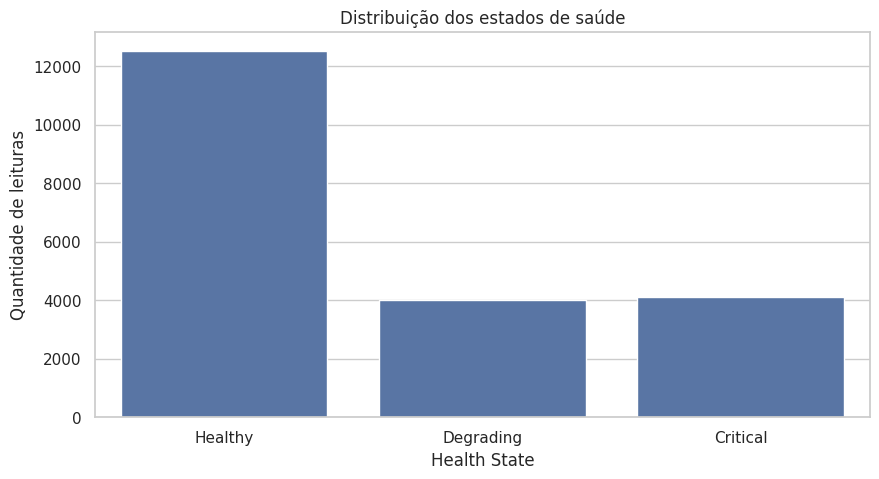

In [7]:
plt.figure(figsize=(10, 5))

sns.countplot(
    data=train_df,
    x="health_state",
    order=["Healthy", "Degrading", "Critical"]
)

plt.title("Distribuição dos estados de saúde")
plt.xlabel("Health State")
plt.ylabel("Quantidade de leituras")

plt.show()

In [8]:
health_mapping = {
    "Healthy": 0,
    "Degrading": 1,
    "Critical": 2
}

inverse_health_mapping = {
    0: "Healthy",
    1: "Degrading",
    2: "Critical"
}

train_df["health_state_encoded"] = train_df["health_state"].map(health_mapping)

train_df[["health_state", "health_state_encoded"]].head()

,health_state,health_state_encoded
0,Healthy,0
1,Healthy,0
2,Healthy,0
3,Healthy,0
4,Healthy,0


# Operational Pattern Analysis

Nesta seção vamos explorar os padrões operacionais dos sensores ao longo do tempo.

O objetivo é entender:
- comportamento estatístico dos sensores;
- regiões operacionais normais;
- sinais de degradação;
- comportamento próximo da falha;
- relação entre sensores e estados de saúde.

Essa abordagem é importante em ambientes industriais porque permite construir sistemas de monitoramento operacional mais interpretáveis e confiáveis.

In [10]:
analysis_sensors = [
    "sensor_4",
    "sensor_7",
    "sensor_11",
    "sensor_12",
    "sensor_15",
    "sensor_21"
]

## Operational Statistical Envelope

Vamos construir um envelope estatístico dos sensores ao longo dos ciclos.

Esse tipo de visualização pode ser utilizado como:
- referência operacional;
- monitoramento de comportamento esperado;
- identificação de desvios;
- suporte para criação de alarmes.

In [11]:
sensor = "sensor_11"

sensor_stats = (
    train_df
    .groupby("time_in_cycles")[sensor]
    .agg(
        ["mean", "std", "min", "max"]
    )
    .reset_index()
)

sensor_stats.head()

,time_in_cycles,mean,std,min,max
0,1,47.3428,0.189753,46.93,47.70
1,2,47.3486,0.177269,47.00,47.72
2,3,47.3609,0.173951,46.85,47.75
3,4,47.3350,0.170344,46.92,47.70
4,5,47.3441,0.172311,46.90,47.75


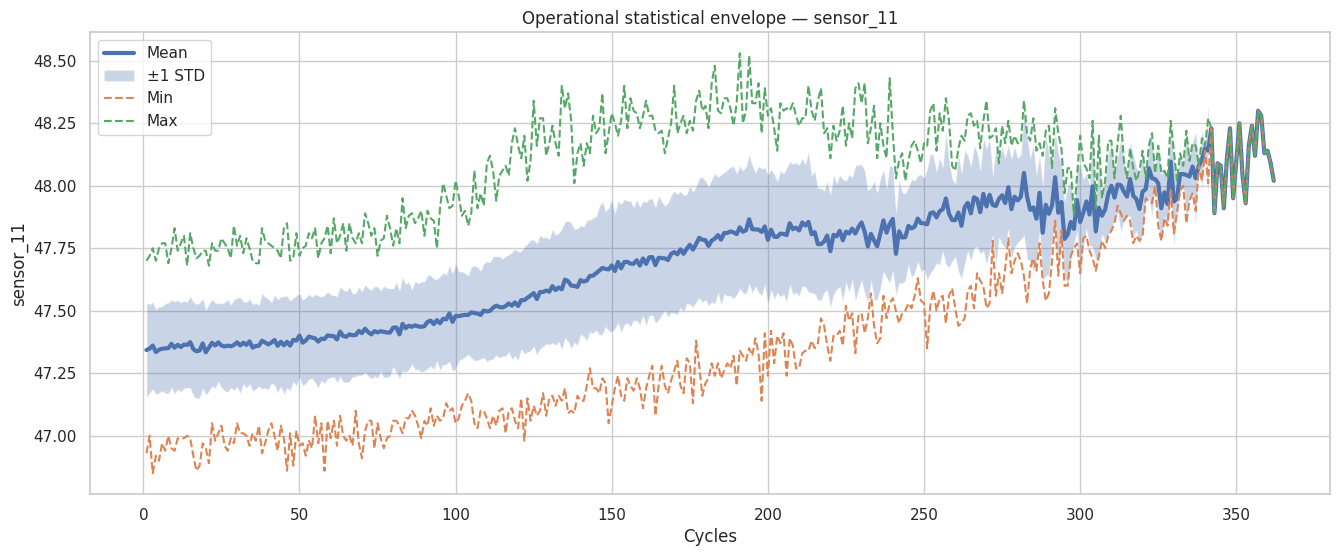

In [12]:
plt.figure(figsize=(16, 6))

plt.plot(
    sensor_stats["time_in_cycles"],
    sensor_stats["mean"],
    linewidth=3,
    label="Mean"
)

plt.fill_between(
    sensor_stats["time_in_cycles"],
    sensor_stats["mean"] - sensor_stats["std"],
    sensor_stats["mean"] + sensor_stats["std"],
    alpha=0.3,
    label="±1 STD"
)

plt.plot(
    sensor_stats["time_in_cycles"],
    sensor_stats["min"],
    linestyle="--",
    linewidth=1.5,
    label="Min"
)

plt.plot(
    sensor_stats["time_in_cycles"],
    sensor_stats["max"],
    linestyle="--",
    linewidth=1.5,
    label="Max"
)

plt.title(
    f"Operational statistical envelope — {sensor}"
)

plt.xlabel("Cycles")
plt.ylabel(sensor)

plt.legend()

plt.show()

In [13]:
health_colors = {
    "Healthy": "#2ca02c",
    "Degrading": "#ffbf00",
    "Critical": "#d62728"
}

## Sensor behavior by health state

Agora vamos visualizar como os sensores se comportam conforme o equipamento transita entre diferentes estados operacionais.

As regiões coloridas representam:
- Verde → Healthy
- Amarelo → Degrading
- Vermelho → Critical

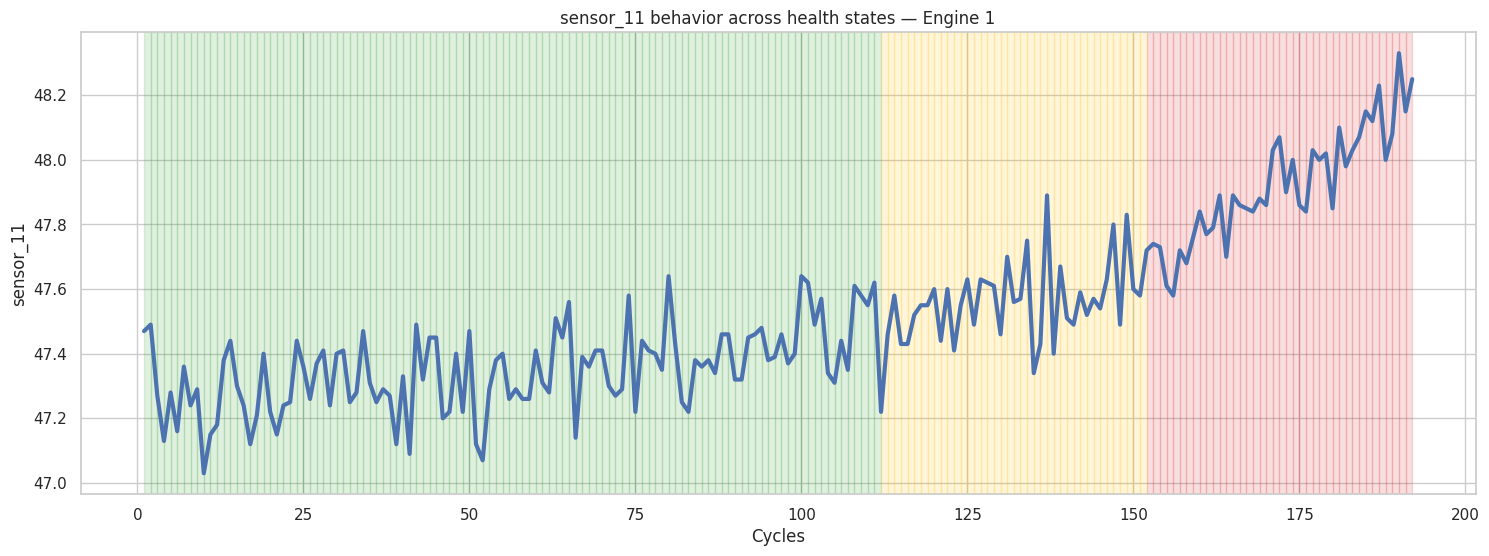

In [14]:
engine_id = 1
sensor = "sensor_11"

engine_df = train_df[
    train_df["unit_number"] == engine_id
].copy()

plt.figure(figsize=(18, 6))

# Plot do sensor
plt.plot(
    engine_df["time_in_cycles"],
    engine_df[sensor],
    linewidth=3
)

# Faixas de health state
for i in range(len(engine_df) - 1):

    state = engine_df.iloc[i]["health_state"]

    plt.axvspan(
        engine_df.iloc[i]["time_in_cycles"],
        engine_df.iloc[i + 1]["time_in_cycles"],
        alpha=0.15,
        color=health_colors[state]
    )

plt.title(
    f"{sensor} behavior across health states — Engine {engine_id}"
)

plt.xlabel("Cycles")
plt.ylabel(sensor)

plt.show()

## Fleet operational envelope vs engine behavior

Agora vamos comparar o comportamento de um motor específico contra o envelope estatístico global da frota.

A ideia é verificar quando o equipamento começa a operar fora da região considerada normal para os sensores.

Esse tipo de visualização é bastante útil para:
- monitoramento operacional;
- detecção de degradação;
- criação de alarmes;
- análise de comportamento anômalo.

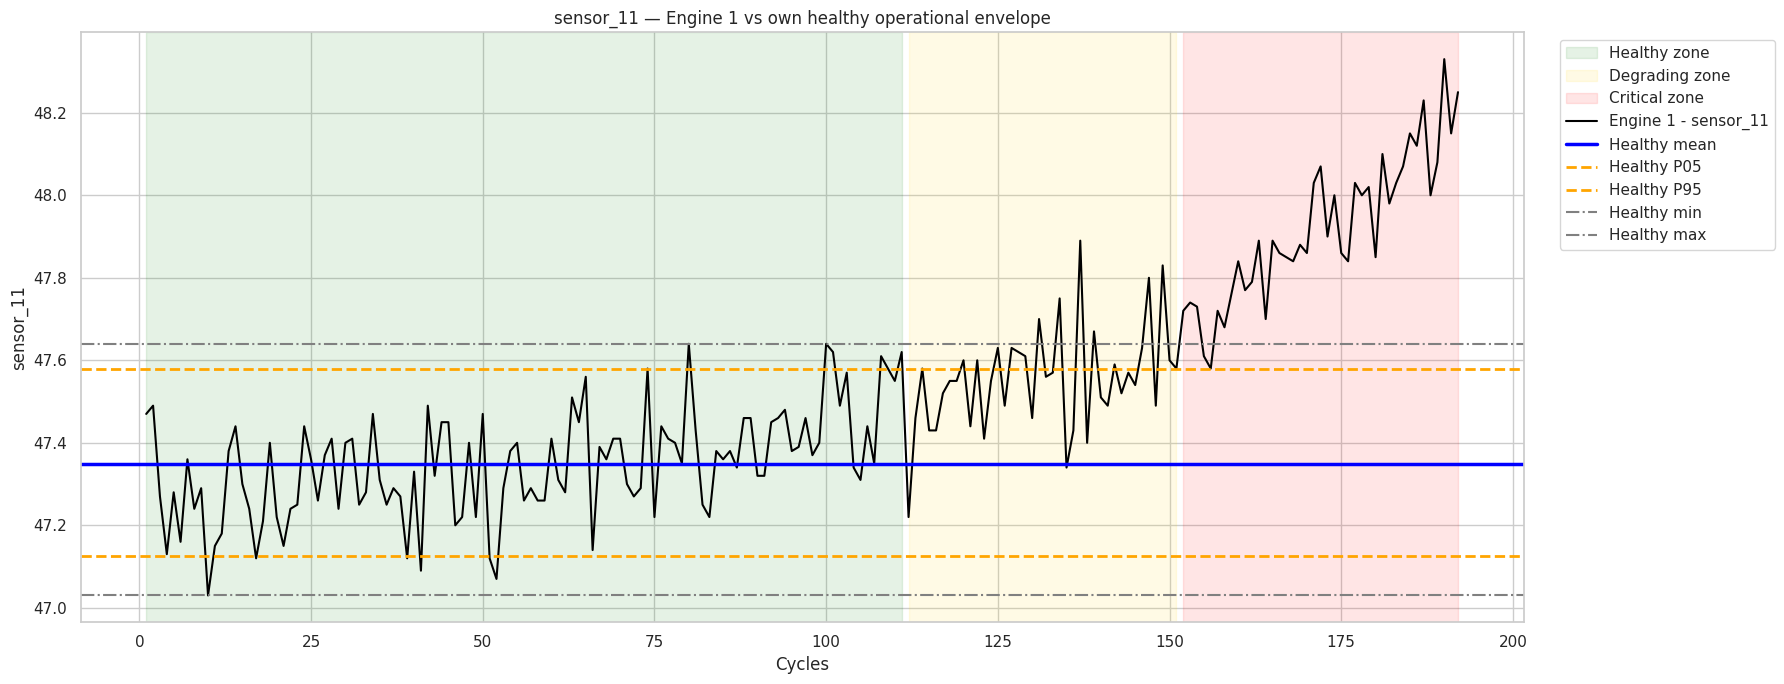

In [23]:
sensor = "sensor_11"
engine_id = 1

engine_df = train_df[
    train_df["unit_number"] == engine_id
].copy()

healthy_reference = engine_df[
    engine_df["health_state"] == "Healthy"
][sensor]

sensor_mean = healthy_reference.mean()
sensor_min = healthy_reference.min()
sensor_max = healthy_reference.max()

p05 = healthy_reference.quantile(0.05)
p95 = healthy_reference.quantile(0.95)

p01 = healthy_reference.quantile(0.01)
p99 = healthy_reference.quantile(0.99)

health_colors = {
    "Healthy": "green",
    "Degrading": "gold",
    "Critical": "red"
}

plt.figure(figsize=(18, 7))

for state, color in health_colors.items():
    state_df = engine_df[engine_df["health_state"] == state]

    if not state_df.empty:
        plt.axvspan(
            state_df["time_in_cycles"].min(),
            state_df["time_in_cycles"].max(),
            color=color,
            alpha=0.10,
            label=f"{state} zone"
        )

plt.plot(
    engine_df["time_in_cycles"],
    engine_df[sensor],
    linewidth=1.5,
    color="black",
    label=f"Engine {engine_id} - {sensor}"
)

plt.axhline(sensor_mean, color="blue", linewidth=2.5, label="Healthy mean")

plt.axhline(p05, color="orange", linewidth=2, linestyle="--", label="Healthy P05")
plt.axhline(p95, color="orange", linewidth=2, linestyle="--", label="Healthy P95")

# plt.axhline(p01, color="red", linewidth=2, linestyle=":", label="Healthy P01")
# plt.axhline(p99, color="red", linewidth=2, linestyle=":", label="Healthy P99")

plt.axhline(sensor_min, color="gray", linewidth=1.5, linestyle="-.", label="Healthy min")
plt.axhline(sensor_max, color="gray", linewidth=1.5, linestyle="-.", label="Healthy max")

plt.title(
    f"{sensor} — Engine {engine_id} vs own healthy operational envelope"
)

plt.xlabel("Cycles")
plt.ylabel(sensor)

plt.legend(
    bbox_to_anchor=(1.02, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()

# Feature Engineering for Health State Classification

Agora vamos construir features temporais para ajudar os modelos de classificação a capturar:

- tendências de degradação;
- instabilidade operacional;
- mudanças abruptas;
- comportamento temporal dos sensores.

Essas variáveis são importantes porque o estado de saúde do equipamento depende não apenas do valor instantâneo do sensor, mas também da sua evolução ao longo do tempo.

In [24]:
feature_sensors = [
    "sensor_4",
    "sensor_7",
    "sensor_11",
    "sensor_12",
    "sensor_15",
    "sensor_21"
]

ROLLING_WINDOW = 5

In [25]:
for sensor in feature_sensors:

    train_df[f"{sensor}_rolling_mean"] = (
        train_df
        .groupby("unit_number")[sensor]
        .transform(
            lambda x: x.rolling(
                window=ROLLING_WINDOW,
                min_periods=1
            ).mean()
        )
    )

In [26]:
for sensor in feature_sensors:

    train_df[f"{sensor}_rolling_std"] = (
        train_df
        .groupby("unit_number")[sensor]
        .transform(
            lambda x: x.rolling(
                window=ROLLING_WINDOW,
                min_periods=1
            ).std()
        )
    )

In [27]:
for sensor in feature_sensors:

    train_df[f"{sensor}_delta"] = (
        train_df
        .groupby("unit_number")[sensor]
        .diff()
    )

In [28]:
for sensor in feature_sensors:

    train_df[f"{sensor}_trend"] = (
        train_df
        .groupby("unit_number")[sensor]
        .diff(periods=3)
    )

In [29]:
train_df = train_df.dropna().reset_index(drop=True)

train_df.shape

(20331, 55)

In [30]:
engineered_features = [
    col for col in train_df.columns
    if (
        "rolling" in col
        or "delta" in col
        or "trend" in col
    )
]

model_features = (
    feature_sensors +
    engineered_features
)

len(model_features)

30

# Baseline Classification Model

Vamos iniciar com Regressão Logística como modelo baseline de classificação.

Apesar de simples, esse modelo fornece:
- interpretabilidade;
- rapidez;
- boa referência inicial;
- entendimento da separabilidade dos estados operacionais.

In [31]:
from sklearn.model_selection import GroupShuffleSplit

X = train_df[model_features]

y = train_df["health_state_encoded"]

groups = train_df["unit_number"]

gss = GroupShuffleSplit(
    n_splits=1,
    test_size=0.2,
    random_state=RANDOM_STATE
)

train_idx, val_idx = next(
    gss.split(X, y, groups=groups)
)

X_train = X.iloc[train_idx]
X_val = X.iloc[val_idx]

y_train = y.iloc[train_idx]
y_val = y.iloc[val_idx]

In [32]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)

In [33]:
baseline_classifier = LogisticRegression(
    max_iter=3000,
    multi_class="multinomial"
)

baseline_classifier.fit(
    X_train_scaled,
    y_train
)

LogisticRegression(max_iter=3000, multi_class='multinomial')

In [34]:
baseline_predictions = baseline_classifier.predict(
    X_val_scaled
)

In [35]:
print(
    classification_report(
        y_val,
        baseline_predictions,
        target_names=[
            "Healthy",
            "Degrading",
            "Critical"
        ]
    )
)

              precision    recall  f1-score   support

     Healthy       0.85      0.92      0.88      2390
   Degrading       0.51      0.34      0.41       800
    Critical       0.82      0.87      0.84       820

    accuracy                           0.79      4010
   macro avg       0.72      0.71      0.71      4010
weighted avg       0.77      0.79      0.78      4010



In [36]:
accuracy = accuracy_score(
    y_val,
    baseline_predictions
)

f1 = f1_score(
    y_val,
    baseline_predictions,
    average="weighted"
)

print(f"Accuracy: {accuracy:.4f}")
print(f"F1 Score: {f1:.4f}")

Accuracy: 0.7948
F1 Score: 0.7797


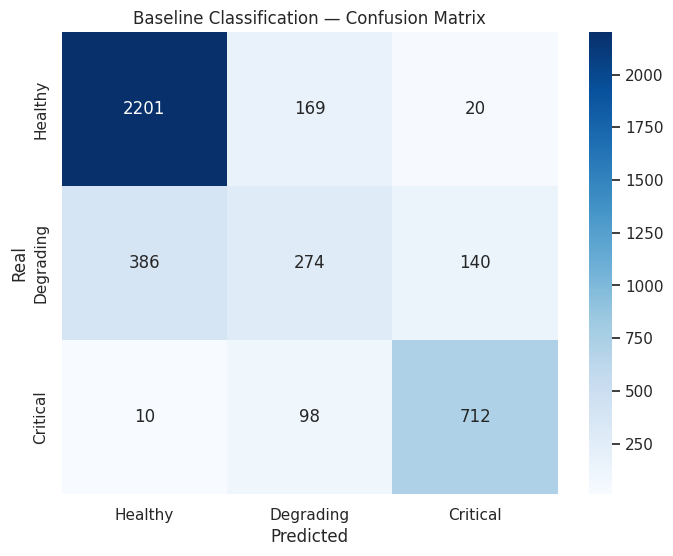

In [37]:
conf_matrix = confusion_matrix(
    y_val,
    baseline_predictions
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    conf_matrix,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=[
        "Healthy",
        "Degrading",
        "Critical"
    ],
    yticklabels=[
        "Healthy",
        "Degrading",
        "Critical"
    ]
)

plt.xlabel("Predicted")
plt.ylabel("Real")

plt.title("Baseline Classification — Confusion Matrix")

plt.show()

# Random Forest Classifier

Agora vamos utilizar Random Forest para classificar os estados de saúde dos equipamentos.

Diferente da Regressão Logística, o Random Forest consegue capturar:
- relações não lineares;
- interações entre sensores;
- padrões operacionais mais complexos.

Isso costuma melhorar significativamente a classificação de estados intermediários de degradação.

In [38]:
from sklearn.ensemble import RandomForestClassifier

rf_classifier = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    random_state=RANDOM_STATE,
    n_jobs=-1
)

In [39]:
rf_classifier.fit(
    X_train,
    y_train
)

RandomForestClassifier(max_depth=10, n_estimators=300, n_jobs=-1,
                       random_state=42)

In [40]:
rf_predictions = rf_classifier.predict(
    X_val
)

In [41]:
print(
    classification_report(
        y_val,
        rf_predictions,
        target_names=[
            "Healthy",
            "Degrading",
            "Critical"
        ]
    )
)

              precision    recall  f1-score   support

     Healthy       0.83      0.95      0.89      2390
   Degrading       0.53      0.31      0.39       800
    Critical       0.88      0.84      0.86       820

    accuracy                           0.80      4010
   macro avg       0.75      0.70      0.71      4010
weighted avg       0.78      0.80      0.78      4010



In [42]:
rf_accuracy = accuracy_score(
    y_val,
    rf_predictions
)

rf_f1 = f1_score(
    y_val,
    rf_predictions,
    average="weighted"
)

print(f"Random Forest Accuracy: {rf_accuracy:.4f}")
print(f"Random Forest F1 Score: {rf_f1:.4f}")

Random Forest Accuracy: 0.8022
Random Forest F1 Score: 0.7820


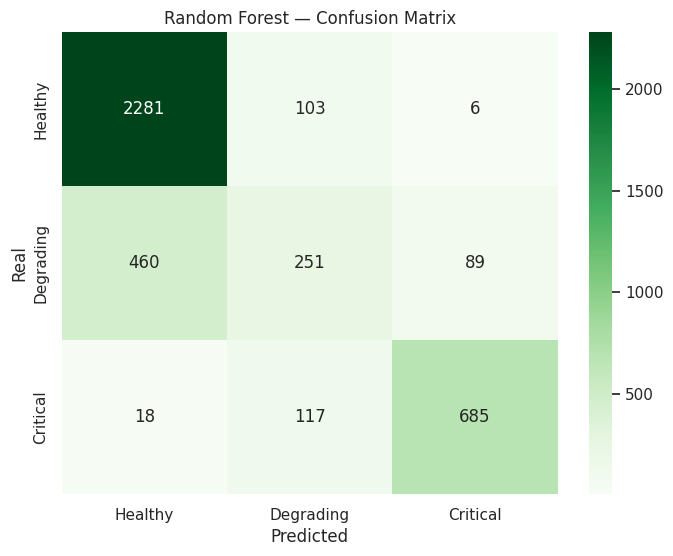

In [43]:
rf_conf_matrix = confusion_matrix(
    y_val,
    rf_predictions
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    rf_conf_matrix,
    annot=True,
    fmt="d",
    cmap="Greens",
    xticklabels=[
        "Healthy",
        "Degrading",
        "Critical"
    ],
    yticklabels=[
        "Healthy",
        "Degrading",
        "Critical"
    ]
)

plt.xlabel("Predicted")
plt.ylabel("Real")

plt.title(
    "Random Forest — Confusion Matrix"
)

plt.show()

In [44]:
comparison_df = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest"
    ],
    "Accuracy": [
        accuracy,
        rf_accuracy
    ],
    "F1 Score": [
        f1,
        rf_f1
    ]
})

comparison_df

,Model,Accuracy,F1 Score
0,Logistic Regression,0.794763,0.779721
1,Random Forest,0.802244,0.781953


In [46]:
rf_feature_importance = pd.DataFrame({
    "feature": model_features,
    "importance": rf_classifier.feature_importances_
})

rf_feature_importance = (
    rf_feature_importance
    .sort_values(
        by="importance",
        ascending=False
    )
)

rf_feature_importance.head(15)

,feature,importance
6,sensor_4_rolling_mean,0.144526
8,sensor_11_rolling_mean,0.120522
10,sensor_15_rolling_mean,0.117026
11,sensor_21_rolling_mean,0.101860
9,sensor_12_rolling_mean,0.076725
7,sensor_7_rolling_mean,0.072300
2,sensor_11,0.055075
0,sensor_4,0.051417
3,sensor_12,0.038331
4,sensor_15,0.031716


# XGBoost Classifier

Agora vamos utilizar XGBoost para classificação dos estados operacionais.

O XGBoost é um dos algoritmos mais utilizados em problemas industriais tabulares devido à sua capacidade de modelar:
- relações não lineares;
- interações complexas;
- padrões temporais;
- fronteiras de decisão mais sofisticadas.

A expectativa é melhorar principalmente a separação da classe intermediária de degradação.

In [47]:
from xgboost import XGBClassifier

xgb_classifier = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE,
    objective="multi:softmax",
    num_class=3,
    eval_metric="mlogloss"
)

In [48]:
xgb_classifier.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=0.8, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.05, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=6, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=300, n_jobs=None, num_class=3, ...)

In [49]:
xgb_predictions = xgb_classifier.predict(
    X_val
)

In [50]:
print(
    classification_report(
        y_val,
        xgb_predictions,
        target_names=[
            "Healthy",
            "Degrading",
            "Critical"
        ]
    )
)

              precision    recall  f1-score   support

     Healthy       0.83      0.94      0.88      2390
   Degrading       0.51      0.32      0.39       800
    Critical       0.85      0.83      0.84       820

    accuracy                           0.79      4010
   macro avg       0.73      0.70      0.70      4010
weighted avg       0.77      0.79      0.78      4010



In [51]:
xgb_accuracy = accuracy_score(
    y_val,
    xgb_predictions
)

xgb_f1 = f1_score(
    y_val,
    xgb_predictions,
    average="weighted"
)

print(f"XGBoost Accuracy: {xgb_accuracy:.4f}")
print(f"XGBoost F1 Score: {xgb_f1:.4f}")

XGBoost Accuracy: 0.7940
XGBoost F1 Score: 0.7753


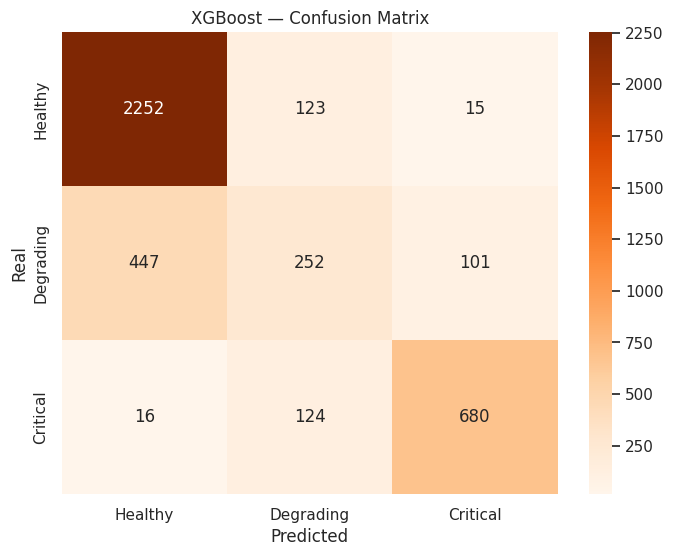

In [52]:
xgb_conf_matrix = confusion_matrix(
    y_val,
    xgb_predictions
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    xgb_conf_matrix,
    annot=True,
    fmt="d",
    cmap="Oranges",
    xticklabels=[
        "Healthy",
        "Degrading",
        "Critical"
    ],
    yticklabels=[
        "Healthy",
        "Degrading",
        "Critical"
    ]
)

plt.xlabel("Predicted")
plt.ylabel("Real")

plt.title(
    "XGBoost — Confusion Matrix"
)

plt.show()

# LightGBM Classifier

Agora vamos avaliar o LightGBM para classificação dos estados operacionais.

O LightGBM é um algoritmo baseado em Gradient Boosting extremamente eficiente para problemas tabulares industriais.

Suas principais vantagens incluem:
- treinamento rápido;
- boa capacidade de generalização;
- modelagem não linear eficiente;
- excelente desempenho em datasets tabulares.

In [53]:
from lightgbm import LGBMClassifier

lgbm_classifier = LGBMClassifier(
    n_estimators=300,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=RANDOM_STATE
)

In [54]:
lgbm_classifier.fit(
    X_train,
    y_train
)

[LightGBM] [Info] Auto-choosing col-wise multi-threading, the overhead of testing was 0.009762 seconds.
You can set `force_col_wise=true` to remove the overhead.
[LightGBM] [Info] Total Bins 7380
[LightGBM] [Info] Number of data points in the train set: 16321, number of used features: 30
[LightGBM] [Info] Start training from score -0.505895
[LightGBM] [Info] Start training from score -1.629302
[LightGBM] [Info] Start training from score -1.604609
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No 

LGBMClassifier(colsample_bytree=0.8, learning_rate=0.05, max_depth=6,
               n_estimators=300, random_state=42, subsample=0.8)

In [55]:
lgbm_predictions = lgbm_classifier.predict(
    X_val
)

In [56]:
print(
    classification_report(
        y_val,
        lgbm_predictions,
        target_names=[
            "Healthy",
            "Degrading",
            "Critical"
        ]
    )
)

              precision    recall  f1-score   support

     Healthy       0.83      0.94      0.88      2390
   Degrading       0.51      0.32      0.39       800
    Critical       0.86      0.83      0.85       820

    accuracy                           0.79      4010
   macro avg       0.73      0.70      0.71      4010
weighted avg       0.77      0.79      0.78      4010



In [57]:
lgbm_accuracy = accuracy_score(
    y_val,
    lgbm_predictions
)

lgbm_f1 = f1_score(
    y_val,
    lgbm_predictions,
    average="weighted"
)

print(f"LightGBM Accuracy: {lgbm_accuracy:.4f}")
print(f"LightGBM F1 Score: {lgbm_f1:.4f}")

LightGBM Accuracy: 0.7945
LightGBM F1 Score: 0.7762


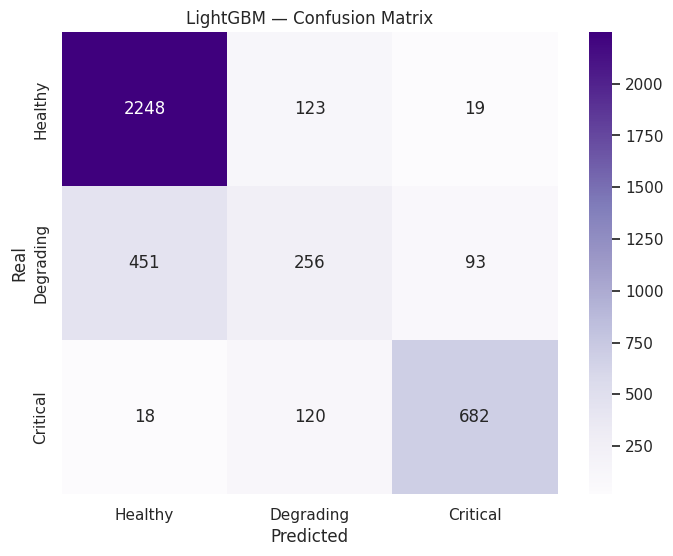

In [58]:
lgbm_conf_matrix = confusion_matrix(
    y_val,
    lgbm_predictions
)

plt.figure(figsize=(8, 6))

sns.heatmap(
    lgbm_conf_matrix,
    annot=True,
    fmt="d",
    cmap="Purples",
    xticklabels=[
        "Healthy",
        "Degrading",
        "Critical"
    ],
    yticklabels=[
        "Healthy",
        "Degrading",
        "Critical"
    ]
)

plt.xlabel("Predicted")
plt.ylabel("Real")

plt.title(
    "LightGBM — Confusion Matrix"
)

plt.show()